In [1]:
from starccato_flow.training.trainer_flow_matching import FlowMatchingTrainer

MPS device found


/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configs

In [2]:
font_family = "sans-serif"
font_name = "Futura"

In [3]:
trainer = FlowMatchingTrainer(num_epochs=256, parameters=["beta1_IC_b", "omega_0(rad|s)","A(km)", "Ye_c_b", "ra", "dec", "d", "psi"])
trainer.load_model_instance(model_path="../outdir/flow_intrinsic_sky_weights.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['beta1_IC_b', 'omega_0(rad|s)', 'A(km)', 'Ye_c_b', 'ra', 'dec', 'd', 'psi']
Intrinsic params: ['beta1_IC_b', 'Ye_c_b']
Sky params: ['omega_0(rad|s)', 'A(km)', 'ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3, 4, 5, 6, 7]
Final flow parameter dimension: 8

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (4 parameters)
beta1_IC_b          : [    0.000000,     0.215477]
omega_0(rad|s)      : [    0.000000,    15.500000]
A(km)               : [  300.000000, 10000.000000]
Ye_c_b              : [    0.246499,     0.282820]


=== Data Split ===
Total signals: 1764
Training signals: 1588
Validation signals: 176
First 5 training indices: [  28  992 1389  878 1099]
First 5 validation indices: [  32  726  945 1158  389]

sTheta Dataset - Parameter Bounds (4 parameters)
b

### Loss Plots

Loaded 256 training loss entries from ../outdir/flow_matching/intrinsic_sky_losses.csv


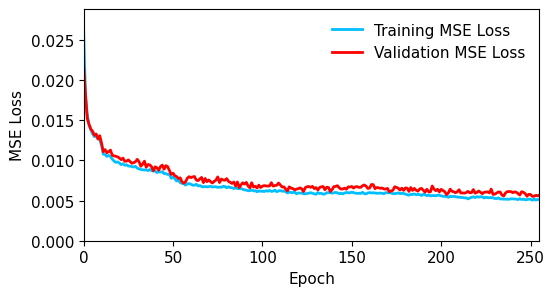

In [4]:
trainer.load_losses(fname="../outdir/flow_matching/intrinsic_sky_losses.csv")
trainer.display_results(fname="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_loss.pdf", background="white", font_family=font_family, font_name=font_name, figsize=(14.5,8), fontsize_title=16, fontsize_tick=11)


hThetaMulti Dataset - Parameter Bounds (8 parameters)
INTRINSIC PARAMETERS:
  beta1_IC_b          : [    0.000000,     0.215477]
  Ye_c_b              : [    0.000000,    15.500000]
  theta_2             : [  300.000000, 10000.000000]
  theta_3             : [    0.246499,     0.282820]

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [    0.000000,     6.283185]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 2000
Multi-channel shape: (2000, 3, 256)
Parameter dimension: 8
Parameters include theta + sky: [ra, dec, d, polar_angle]
✓ Created validation dataset with 2000 signals
  Processed 400/2000 signals...
  Processed 800/2000 signals...
  Processed 1200/2000 signals...
  Processed 1600/2000 signals...
  Processed 2000/2000 signals...
Generating p-p coverage plot...
✓ Saved p-p c

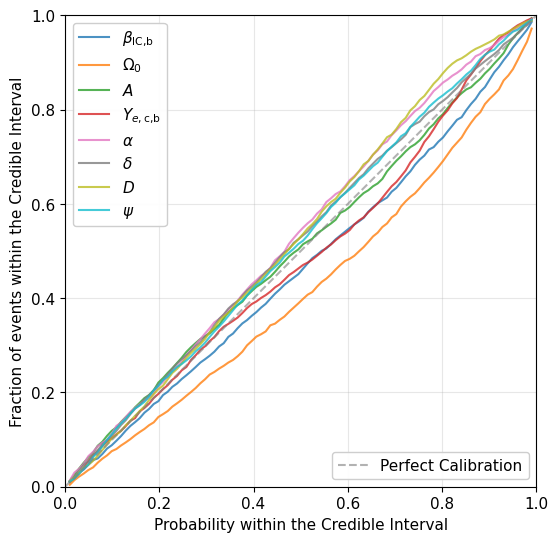

In [5]:
trainer.plot_pp_coverage_validation(background="white", font_family=font_family, font_name=font_name, fname="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_pp_plot.pdf", figsize=(14.5,14.5))

### Signal and Corner Plot


hThetaMulti Dataset - Parameter Bounds (8 parameters)
INTRINSIC PARAMETERS:
  beta1_IC_b          : [    0.000000,     0.215477]
  Ye_c_b              : [    0.000000,    15.500000]
  theta_2             : [  300.000000, 10000.000000]
  theta_3             : [    0.246499,     0.282820]

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [    0.000000,     6.283185]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 1
Multi-channel shape: (1, 3, 256)
Parameter dimension: 8
Parameters include theta + sky: [ra, dec, d, polar_angle]


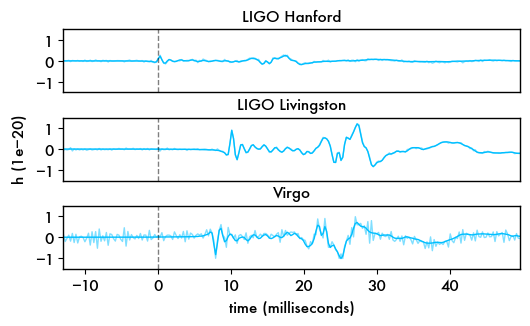


=== RAW FLOW OUTPUT (Physics-Aware Normalized Space) ===
Shape: (5000, 11) (11D: intrinsic params + 2D cyclic + 1D distance)
Overall range: [-1.4988, 1.2718]
Note: (cos, sin) pairs should be in [-1, 1], distance in [0, 1]

=== DENORMALIZED OUTPUT (Physical Units) - Physics-Aware ===
  beta1_IC_b: min=-0.0537, max=0.0802
             bounds: [0.0000, 0.2155]
  omega_0(rad|s): min=-3.4394, max=7.8295
             bounds: [0.0000, 15.5000]
  A(km)     : min=-653.3214, max=10950.4023
             bounds: [300.0000, 10000.0000]
  Ye_c_b    : min=0.2578, max=0.2864
             bounds: [0.2465, 0.2828]
  ra        : min=0.3545, max=5.8269
             bounds: [0.0000, 6.2832]
  dec       : min=-0.9133, max=1.1601
             bounds: [-1.5708, 1.5708]
  d         : min=0.1534, max=10.0255
             bounds: [0.0000, 10.0000]
  psi       : min=0.0614, max=2.7430
             bounds: [0.0000, 3.1416]
Posterior sampling and denormalisation took 0.42s

Plot axis ranges (from plotting_defaults

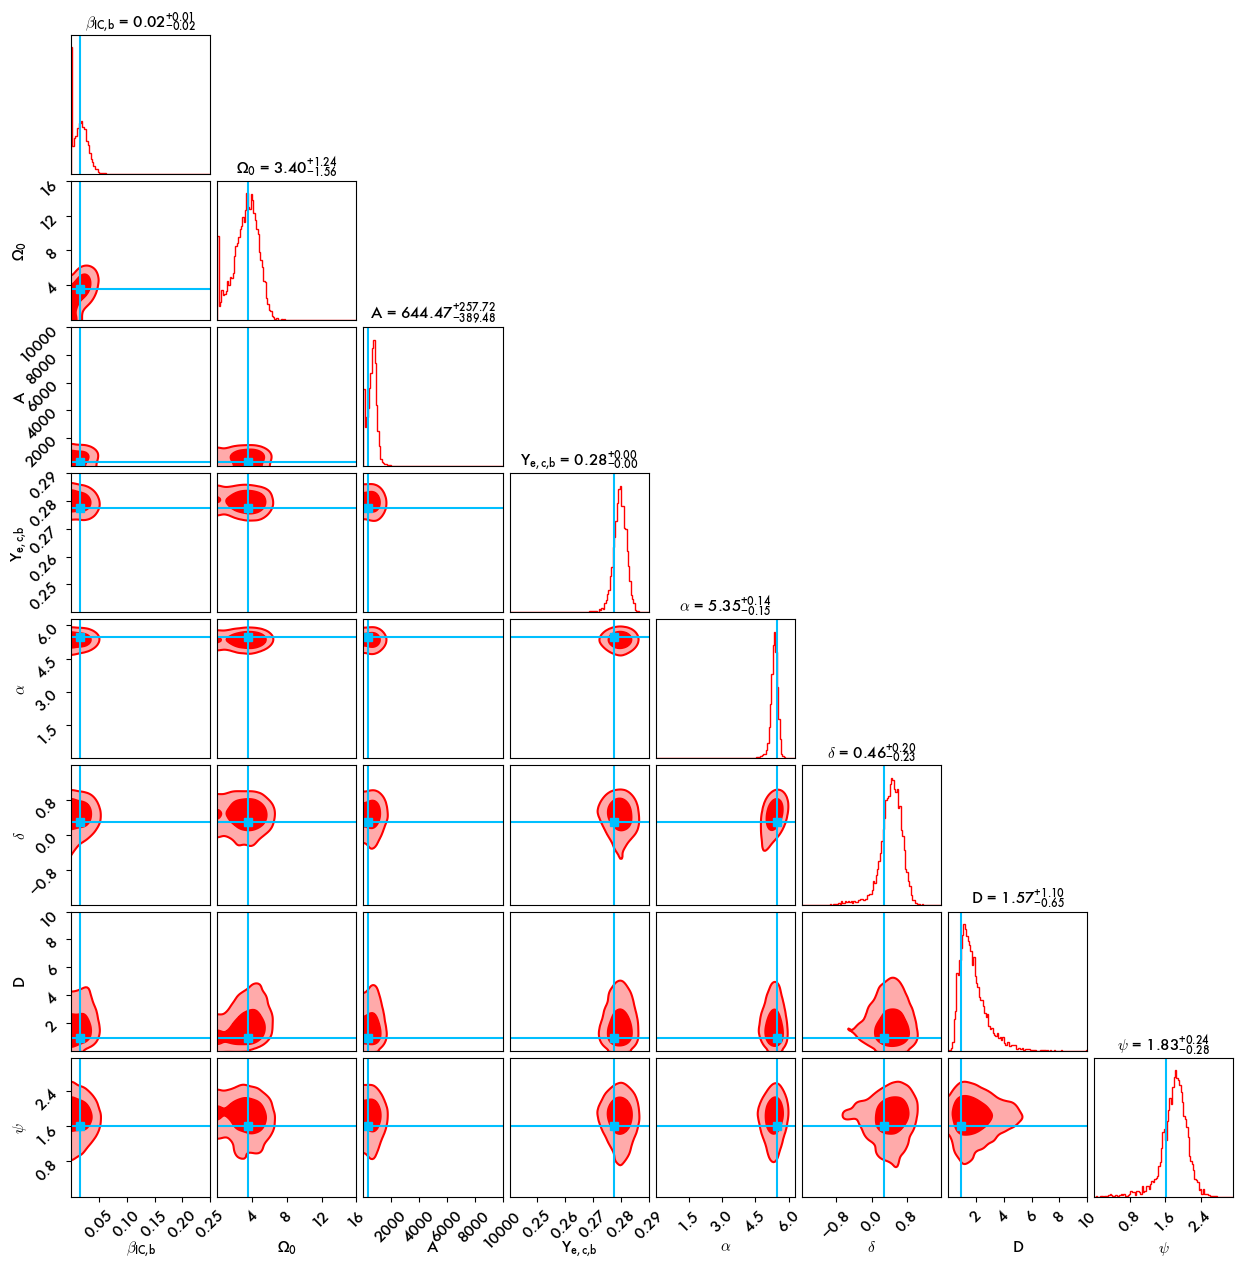


True parameters to plot:
  beta1_IC_b: 0.016793
  omega_0(rad|s): 3.500000
  A(km): 300.000000
  Ye_c_b: 0.277500
  ra: 5.483230
    RA in degrees: 314.17°
  dec: 0.290069
    Dec in degrees: 16.62°
  d: 0.920868
  psi: 1.607935

Sky Localisation Plot Debug:
  ra_idx: 4, dec_idx: 5
  true_param_denorm shape: (8,)
  parameters_to_estimate: ['beta1_IC_b', 'omega_0(rad|s)', 'A(km)', 'Ye_c_b', 'ra', 'dec', 'd', 'psi']
  true_ra: -0.799956 rad = -45.83°
  true_dec: 0.290069 rad = 16.62°
914

Galactic Center Direction:
  RA:  4.649646 rad = 266.41°
  Dec: -0.505032 rad = -28.94°



/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')


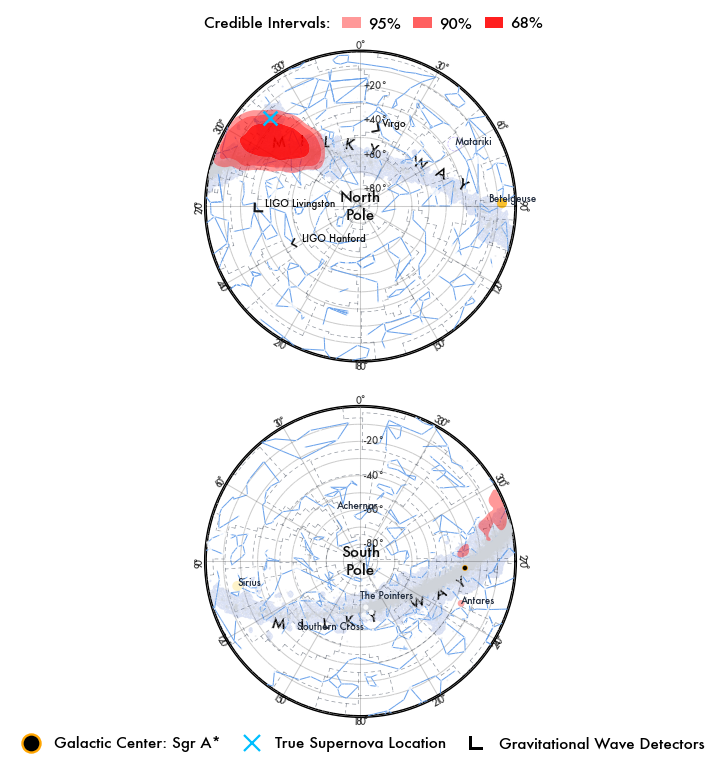

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv
✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv


/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/plotting/parameters.py:935: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


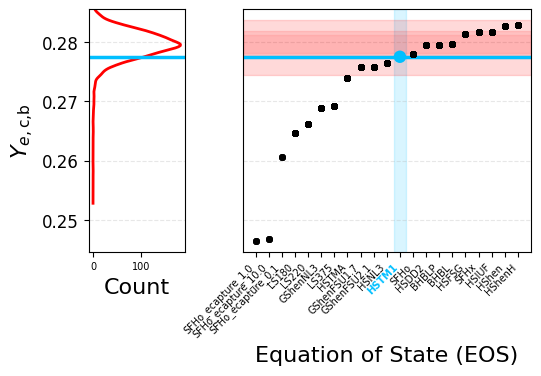

In [6]:
trainer.run_parameter_estimation(signal_idx=1, d=1.0, num_samples=5000, fname_signal="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_signal.pdf", fname_posterior="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_posterior.pdf", fname_posterior_sky="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_posterior_sky.pdf", fname_eos_ye="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_ye_eos_posterior.pdf", background="white", font_family=font_family, font_name=font_name, fontsize_tick=11, fontsize_title=11, figsize_corner=(32,32))

### For just Sky Parameters

In [7]:
trainer_sky = FlowMatchingTrainer(num_epochs=256, parameters=["ra", "dec", "d", "psi"])
trainer_sky.load_model_instance(model_path="../outdir/flow_sky_weights.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['ra', 'dec', 'd', 'psi']
Intrinsic params: []
Sky params: ['ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3]
Final flow parameter dimension: 4

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (0 parameters)


=== Data Split ===
Total signals: 1764
Training signals: 1588
Validation signals: 176
First 5 training indices: [  28  992 1389  878 1099]
First 5 validation indices: [  32  726  945 1158  389]

sTheta Dataset - Parameter Bounds (0 parameters)


sTheta Dataset - Parameter Bounds (0 parameters)


Verifying data alignment:
Number of signals: 1588
Number of parameter sets: 1588
Parameter names: []
First few parameter values:
[]

Verifying data alignment:
Number of signals: 176
Number of parameter sets: 176
Parameter names: []
First few parameter values:
[]



### Losses

Loaded 256 training loss entries from ../outdir/flow_matching/sky_losses.csv


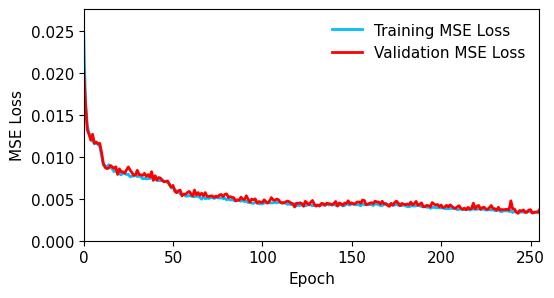

In [8]:
trainer_sky.load_losses(fname="../outdir/flow_matching/sky_losses.csv")
trainer_sky.display_results(fname="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_loss.pdf", background="white", font_family=font_family, font_name=font_name, fontsize_title=11, fontsize_tick=11, figsize=(14.5,8))

### P-P Plot

In [ ]:
trainer_sky.plot_pp_coverage_validation(background="white", font_family="Serif", font_name="Times New Roman", fname="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_pp_plot.pdf", figsize=(14.5,14.5))


hThetaMulti Dataset - Parameter Bounds (4 parameters)
INTRINSIC PARAMETERS:

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [    0.000000,     6.283185]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 2000
Multi-channel shape: (2000, 3, 256)
Parameter dimension: 4
Parameters include theta + sky: [ra, dec, d, polar_angle]
✓ Created validation dataset with 2000 signals
  Processed 400/2000 signals...
  Processed 800/2000 signals...
  Processed 1200/2000 signals...


### Signal and Corner Plot

In [ ]:
trainer_sky.run_parameter_estimation(signal_idx=1, d=8.0, num_samples=5000, fname_signal="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_signal.pdf", fname_posterior="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_posterior.pdf", fname_posterior_sky="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_posterior_sky.pdf", background="white", font_family=font_family, font_name=font_name, fontsize_title=11, fontsize_tick=11)

### Add, Commit, Push

In [ ]:
import subprocess

# Add all files
subprocess.run(["git", "pull"], cwd="../../2025-Statistics-Masters-Thesis")
subprocess.run(["git", "add", "."], cwd="../../2025-Statistics-Masters-Thesis")
# Commit
subprocess.run(["git", "commit", "-m", "Update Plots"], cwd="../../2025-Statistics-Masters-Thesis")
# Push
subprocess.run(["git", "push"], cwd="../../2025-Statistics-Masters-Thesis")